# Hospital Readmission Prediction

## Project Goal

The goal of this notebook is to predict whether a patient will be **readmitted to the hospital within 30 days** of discharge, using patient information such as vital signs, prior healthcare visits, and diagnosis-related details.

## Approach

- **Algorithm:** Logistic Regression — a simple, interpretable algorithm commonly used for binary classification (Yes/No) problems.
- **Regularization:** L2 regularization is applied to help reduce overfitting by discouraging overly large coefficients.
- **Evaluation:** ROC-AUC is used as the main metric to evaluate how well the model separates readmitted patients from non-readmitted patients across different classification thresholds. Accuracy, precision, recall, and F1-score are also reported.
- **Error trade-offs:** False negatives (missing a patient who will be readmitted) and false positives (flagging a patient who will not be readmitted) have different practical implications, which are discussed later in the notebook.

## ⚠️ Important Note About the Data

The dataset used in this notebook, `hospital_readmission.csv`, is **entirely synthetic** — it was randomly generated in a separate notebook (`01_Create_Synthetic_Hospital_Dataset.ipynb`) purely for **educational purposes**. It does **not** represent real patients or real hospital outcomes. Any patterns the model learns reflect the synthetic data generation process, not real-world clinical relationships. Results in this notebook should be interpreted only as a demonstration of a machine learning workflow, not as clinically validated findings.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


## 2. Load the Dataset

We load the synthetic dataset that was already created and saved in the previous notebook (`01_Create_Synthetic_Hospital_Dataset.ipynb`). We are not creating any new data here — just reading the existing CSV file.


In [2]:
# Load the synthetic dataset
df = pd.read_csv("/content/hospital_readmission.csv")

df.head()


,age,gender,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
0,69,Male,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,0
1,32,Male,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,1
2,89,Male,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,0
3,78,Male,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,1
4,38,Female,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,0


In [3]:
# Check the shape of the dataset (rows, columns)
df.shape


(10000, 16)

In [4]:
# Check column data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   gender                10000 non-null  object 
 2   heart_rate            10000 non-null  float64
 3   systolic_bp           10000 non-null  float64
 4   diastolic_bp          10000 non-null  float64
 5   temperature           10000 non-null  float64
 6   oxygen_saturation     10000 non-null  float64
 7   num_prior_visits      10000 non-null  int64  
 8   num_emergency_visits  10000 non-null  int64  
 9   num_inpatient_visits  10000 non-null  int64  
 10  num_diagnoses         10000 non-null  int64  
 11  length_of_stay        10000 non-null  int64  
 12  diabetes              10000 non-null  int64  
 13  hypertension          10000 non-null  int64  
 14  previous_readmission  10000 non-null  int64  
 15  readmitted_30_days  

## 3. Basic Data Inspection

Before building any model, it's important to check the basic structure and quality of the data: column names, missing values, duplicate rows, and summary statistics.


In [5]:
# List all column names
df.columns


Index(['age', 'gender', 'heart_rate', 'systolic_bp', 'diastolic_bp',
       'temperature', 'oxygen_saturation', 'num_prior_visits',
       'num_emergency_visits', 'num_inpatient_visits', 'num_diagnoses',
       'length_of_stay', 'diabetes', 'hypertension', 'previous_readmission',
       'readmitted_30_days'],
      dtype='object')

In [6]:
# Check for missing values in each column
df.isnull().sum()


,0
age,0
gender,0
heart_rate,0
systolic_bp,0
diastolic_bp,0
temperature,0
oxygen_saturation,0
num_prior_visits,0
num_emergency_visits,0
num_inpatient_visits,0


In [7]:
# Check for duplicate rows
df.duplicated().sum()


np.int64(0)

In [8]:
# View summary statistics for numeric columns
df.describe()


,age,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.018800,78.139500,124.892900,79.921000,98.203170,97.005610,1.988500,0.99440,1.02380,4.977600,7.545200,0.299800,0.402100,0.252600,0.474300
std,21.051422,12.061848,17.825757,10.022964,0.801406,2.022893,1.406544,1.00313,1.01328,2.560577,4.039949,0.458193,0.490346,0.434525,0.499364
min,18.000000,32.000000,59.000000,35.000000,94.800000,88.700000,0.000000,0.00000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,70.000000,113.000000,73.000000,97.700000,95.600000,1.000000,0.00000,0.00000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,78.000000,125.000000,80.000000,98.200000,97.000000,2.000000,1.00000,1.00000,5.000000,8.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,86.000000,137.000000,87.000000,98.700000,98.400000,3.000000,2.00000,2.00000,7.000000,11.000000,1.000000,1.000000,1.000000,1.000000
max,90.000000,132.000000,191.000000,117.000000,101.000000,104.500000,12.000000,7.00000,7.00000,9.000000,14.000000,1.000000,1.000000,1.000000,1.000000


**Interpretation:** The cells above show whether any columns contain missing values, whether any duplicate rows exist, and the overall range/spread of the numeric columns. Based on the actual output shown above, the dataset generation process was designed to avoid missing values, and the descriptive statistics show that values fall within the realistic ranges used when the synthetic data was created.


## 4. Target Variable Analysis

Here we examine the distribution of our target column, `readmitted_30_days`, to understand how many patients were readmitted within 30 days versus how many were not.


In [9]:
# Count of patients in each class
df["readmitted_30_days"].value_counts()


,count
readmitted_30_days,
0,5257
1,4743


In [10]:
# Percentage of patients in each class
df["readmitted_30_days"].value_counts(normalize=True) * 100


,proportion
readmitted_30_days,
0,52.57
1,47.43


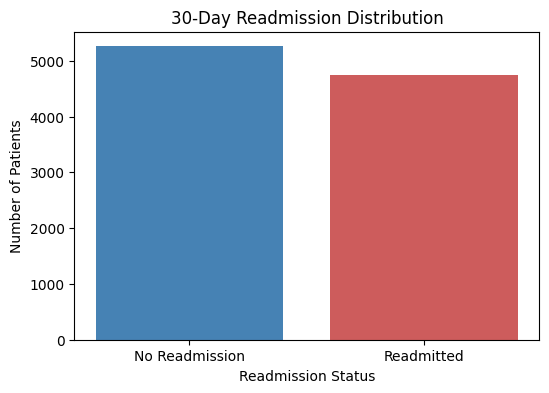

In [11]:
# Simple bar chart of the target distribution
counts = df["readmitted_30_days"].value_counts().sort_index()
labels = ["No Readmission", "Readmitted"]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=["steelblue", "indianred"])
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()


**Interpretation:** Based on the counts and percentages shown above, the two classes are not evenly split — one class (no readmission) has noticeably more patients than the other (readmitted). This means the target variable is **imbalanced** in this synthetic dataset, which is common in real readmission data as well. This is one reason we look at metrics beyond accuracy, such as precision, recall, and ROC-AUC, later in this notebook.


## 5. Exploratory Data Analysis (EDA)

Let's explore a few relationships in the data that may be relevant to hospital readmission. Since this is a synthetic dataset, we describe patterns descriptively rather than drawing real clinical conclusions.


### Age Distribution

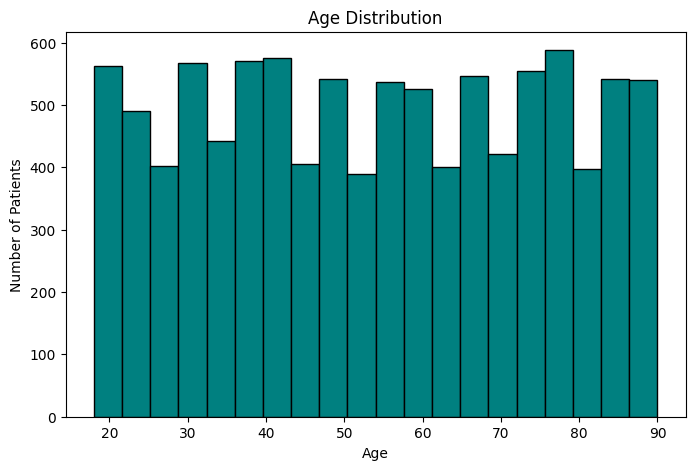

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="teal", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


**Interpretation:** The histogram shows how patient ages are spread across the dataset. Patients with higher values appear to have a different readmission pattern in this synthetic dataset, which we explore further below.


### Readmission by Previous Readmission History

In [13]:
# Compare average 30-day readmission rate for patients with vs. without a previous readmission
readmit_rate_by_prev = df.groupby("previous_readmission")["readmitted_30_days"].mean()
readmit_rate_by_prev


,readmitted_30_days
previous_readmission,
0,0.413968
1,0.652811


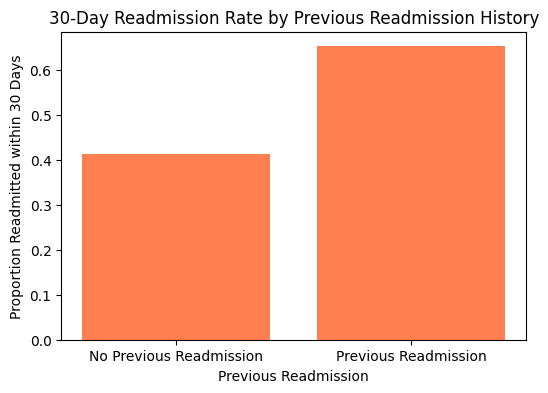

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["No Previous Readmission", "Previous Readmission"],
    readmit_rate_by_prev.values,
    color="coral"
)
plt.title("30-Day Readmission Rate by Previous Readmission History")
plt.xlabel("Previous Readmission")
plt.ylabel("Proportion Readmitted within 30 Days")
plt.show()


**Interpretation:** Patients with a history of previous readmission appear to have a different 30-day readmission rate compared to those without, in this synthetic dataset.


### Prior Visits and Readmission

In [15]:
# Compare average number of prior visits for readmitted vs. non-readmitted patients
prior_visits_avg = df.groupby("readmitted_30_days")["num_prior_visits"].mean()
prior_visits_avg


,num_prior_visits
readmitted_30_days,
0,1.908313
1,2.077377


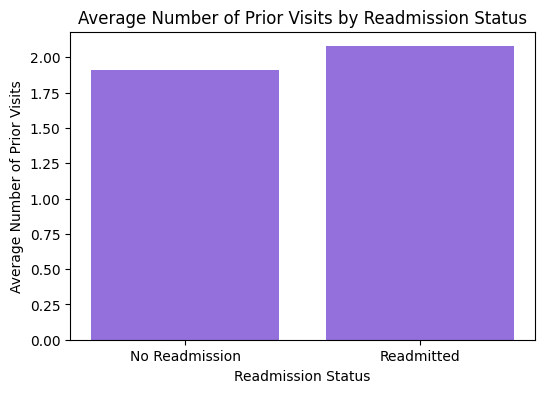

In [16]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["No Readmission", "Readmitted"],
    prior_visits_avg.values,
    color="mediumpurple"
)
plt.title("Average Number of Prior Visits by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Average Number of Prior Visits")
plt.show()


**Interpretation:** Patients with more prior visits appear to have a different readmission pattern in this synthetic dataset compared to patients with fewer prior visits.


### Length of Stay Distribution

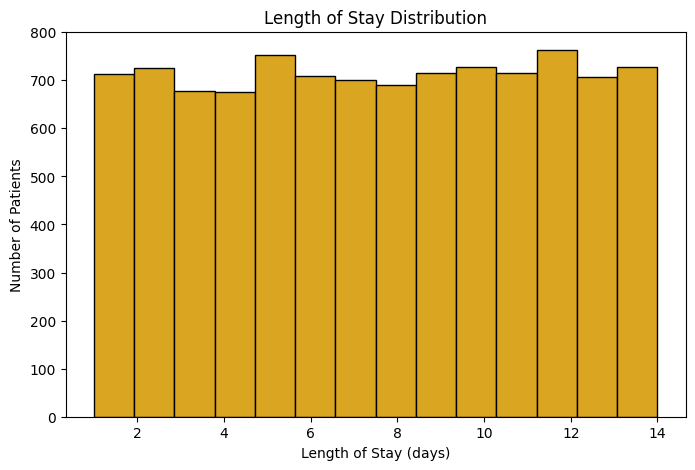

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["length_of_stay"], bins=14, color="goldenrod", edgecolor="black")
plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.show()


**Interpretation:** The distribution above shows how long patients stayed in the hospital in this synthetic dataset. Longer hospital stays appear to be associated with a different readmission pattern, which the model will attempt to learn from during training.


## 6. Prepare Features and Target

We separate the dataset into:
- **X** — the input features used to make predictions.
- **y** — the target we are trying to predict (`readmitted_30_days`).

The `gender` column is categorical (text values like "Male"/"Female"), but machine learning models like Logistic Regression require numeric input. We convert `gender` into a numeric format using **one-hot encoding**, which creates a new column representing the category as 0s and 1s.


In [18]:
# Separate features (X) and target (y)
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

# Convert the categorical "gender" column into numeric form
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

X.head()


,age,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,gender_Male
0,69,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,True
1,32,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,True
2,89,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,True
3,78,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,True
4,38,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,False


## 7. Train-Test Split

We split the data into a **training set** (used to fit the model) and a **testing set** (used to evaluate the model on unseen data).

- **80%** of the data is used for training.
- **20%** of the data is used for testing.
- `stratify=y` ensures both the training and testing sets have a similar proportion of readmitted vs. non-readmitted patients, which is important since our target is imbalanced.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (8000, 15)
X_test shape : (2000, 15)
y_train shape: (8000,)
y_test shape : (2000,)


## 8. Feature Scaling

Logistic Regression with L2 regularization is sensitive to the scale of the input features, because the regularization penalty is applied to the size of the coefficients. If features have very different scales (e.g., `age` ranging 18–90 vs. `oxygen_saturation` ranging 85–100), the model may unfairly penalize some features more than others. **StandardScaler** rescales each feature to have a mean of 0 and a standard deviation of 1.

**Important:** The scaler is fit only on the training data, then used to transform both the training and testing data. This avoids "leaking" information from the test set into the training process.


In [20]:
scaler = StandardScaler()

# Fit the scaler on the training data only, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 9. Build the Logistic Regression Model

We now train a Logistic Regression model with **L2 regularization**:

- **Logistic Regression** is a widely used algorithm for binary classification problems — it estimates the probability that a given patient belongs to the positive class (readmitted).
- **L2 regularization** (the default penalty) discourages the model from assigning overly large coefficients to any single feature, which helps reduce overfitting.
- **C=1.0** controls the strength of the regularization. Smaller values of `C` apply stronger regularization; larger values apply weaker regularization.
- Once trained, the model can output the **probability** of 30-day readmission for each patient, not just a yes/no prediction.


In [21]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    random_state=42
)

model.fit(X_train_scaled, y_train)


LogisticRegression(random_state=42, solver='liblinear')

## 10. Make Predictions

We use the trained model to make two kinds of predictions on the test set:

- **`y_pred`** — the predicted class (0 = no readmission, 1 = readmission), using the model's default 0.5 probability threshold.
- **`y_prob`** — the predicted **probability** of 30-day readmission for each patient, which gives more detail than just a 0/1 label.


In [22]:
# Predicted class labels (0 or 1)
y_pred = model.predict(X_test_scaled)

# Predicted probability of readmission (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Look at the first few predicted probabilities
y_prob[:10]


array([0.30302938, 0.46926886, 0.25043553, 0.40438161, 0.33883159,
       0.59922348, 0.55569071, 0.63118631, 0.24265064, 0.37934412])

## 11. Model Evaluation

We now evaluate the model's performance on the test set using several standard classification metrics.


In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


Accuracy : 0.6565
Precision: 0.6502293577981652
Recall   : 0.5974710221285564
F1 Score : 0.6227347611202636
ROC-AUC  : 0.7190121506037203


In [24]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.66      0.71      0.68      1051
           1       0.65      0.60      0.62       949

    accuracy                           0.66      2000
   macro avg       0.66      0.65      0.65      2000
weighted avg       0.66      0.66      0.66      2000



**What these metrics mean:**

- **Accuracy** — the overall proportion of correct predictions (both classes combined). This can be misleading when the classes are imbalanced.
- **Precision** — of all patients the model predicted as high-risk (readmitted), the proportion who were actually readmitted. High precision means fewer "false alarms."
- **Recall** — of all patients who were actually readmitted, the proportion the model correctly identified. High recall means fewer missed at-risk patients.
- **F1-score** — a single number that balances precision and recall.
- **ROC-AUC** — measures how well the model separates readmitted patients from non-readmitted patients across *all* possible classification thresholds, not just the default 0.5 cutoff. A value of 0.5 means no better than random guessing, and 1.0 means perfect separation.

The specific values shown above should be interpreted in context — none of these metrics is automatically "good" or "bad" without considering the goals and constraints of the application.


## 12. Confusion Matrix

The confusion matrix shows how the model's predictions compare to the actual outcomes, broken down into four categories.


In [25]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[746, 305],
       [382, 567]])

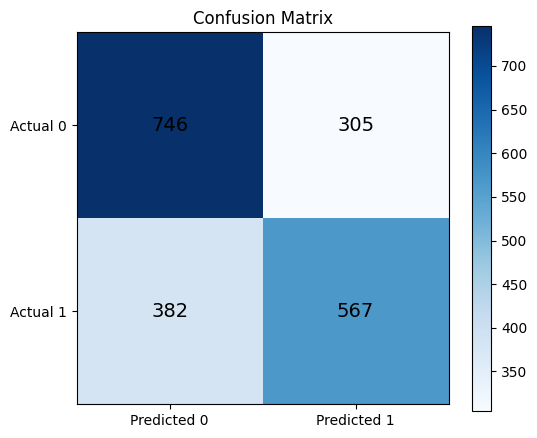

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual 0", "Actual 1"])

# Add the count values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)

ax.set_title("Confusion Matrix")
plt.colorbar(im)
plt.show()


**Reading the confusion matrix:**

- **True Negative (top-left):** Patient was not readmitted, and the model correctly predicted "no readmission."
- **False Positive (top-right):** Patient was not readmitted, but the model incorrectly predicted "readmission."
- **False Negative (bottom-left):** Patient was readmitted, but the model incorrectly predicted "no readmission."
- **True Positive (bottom-right):** Patient was readmitted, and the model correctly predicted "readmission."


## 13. ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the trade-off between the **True Positive Rate** (recall) and the **False Positive Rate** as the classification threshold changes. A curve that bows further toward the top-left corner indicates better separation between the two classes. The dashed diagonal line represents random guessing.


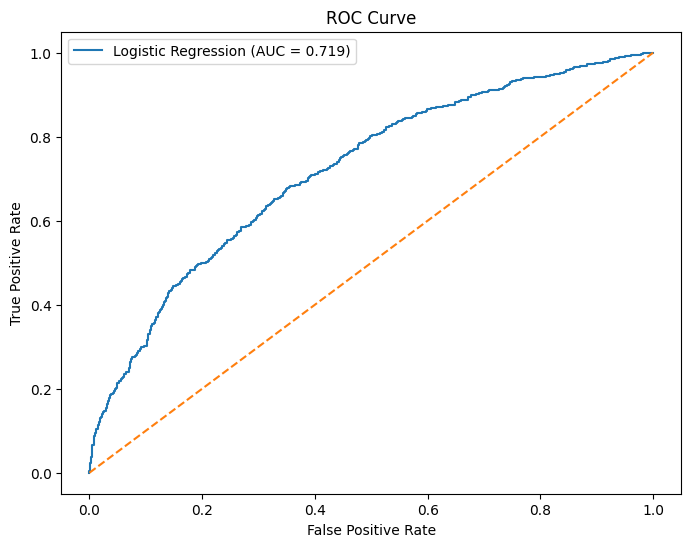

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


As reported above, the model achieved an **ROC-AUC of the value calculated earlier** on the test set, which reflects how well it separates the two classes across all thresholds, not just the default 0.5 cutoff.


## 14. Feature Coefficients / Interpretation

One advantage of Logistic Regression is that it is interpretable — we can directly examine the coefficient learned for each feature.


In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients


,Feature,Coefficient
13,previous_readmission,0.478699
0,age,0.349663
9,num_diagnoses,0.267604
1,heart_rate,0.243918
11,diabetes,0.220991
8,num_inpatient_visits,0.202099
10,length_of_stay,0.191617
2,systolic_bp,0.187519
12,hypertension,0.171783
7,num_emergency_visits,0.131207


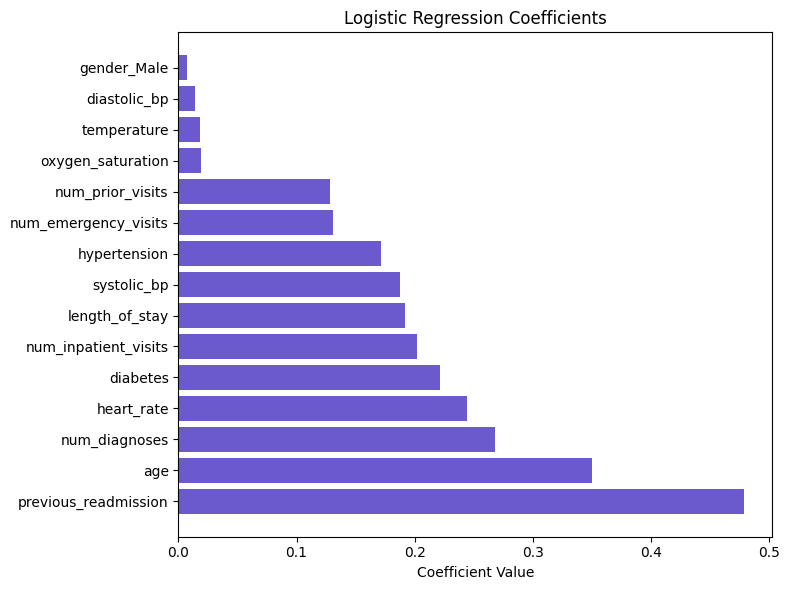

In [29]:
plt.figure(figsize=(8, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color="slateblue")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


**Interpreting the coefficients:**

- **Positive coefficients** are associated with higher predicted log-odds of 30-day readmission — the model learned that higher values of these (scaled) features push the prediction toward "readmitted."
- **Negative coefficients** are associated with lower predicted log-odds of readmission.
- **Larger absolute coefficients** indicate a stronger influence on the model's predictions, subject to the feature scaling applied and the specific model configuration used.

⚠️ **Important:** These coefficients reflect patterns that were built into the *synthetic* data generation process in the previous notebook. They are **not** causal medical effects, and they should not be interpreted as clinical evidence. No feature "causes" readmission in this analysis — the model has simply learned the associations present in this synthetic dataset.


## 15. Clinical Cost of False Negatives vs. False Positives

Understanding the practical implications of prediction errors is important in a healthcare context.

### False Negative
A patient who **will actually be readmitted** within 30 days is predicted as **not** being readmitted.

**Potential implication:**
- The patient may not receive additional follow-up or intervention intended for higher-risk patients.
- This could represent a missed opportunity to provide additional support before a readmission occurs.

### False Positive
A patient who **will not be readmitted** is predicted as **high risk**.

**Potential implication:**
- Additional monitoring, follow-up calls, or healthcare resources may be used unnecessarily.
- This can increase workload and costs for hospital staff.

In a real clinical setting, the relative cost of these two types of errors would need to be determined together with clinicians and healthcare administrators — it is not something a model alone can decide. This notebook does not claim that false negatives are always more important than false positives, or vice versa.


## 16. Optional Threshold Analysis

By default, the model classifies a patient as "readmitted" if the predicted probability is 0.5 or higher. However, this threshold can be adjusted. Let's see how changing the threshold affects precision, recall, and F1-score.


In [30]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for t in thresholds_to_test:
    y_pred_threshold = (y_prob >= t).astype(int)

    t_precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    t_recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    t_f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    threshold_results.append({
        "Threshold": t,
        "Precision": t_precision,
        "Recall": t_recall,
        "F1 Score": t_f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,Threshold,Precision,Recall,F1 Score
0,0.3,0.538510,0.906217,0.675570
1,0.4,0.596308,0.782929,0.676993
2,0.5,0.650229,0.597471,0.622735
3,0.6,0.732839,0.416228,0.530914
4,0.7,0.787645,0.214963,0.337748


**Observation:** Based on the table above, lower thresholds generally identify more patients as high-risk (higher recall, but often lower precision), while higher thresholds make the model more selective (typically higher precision, but often lower recall). Changing the threshold shifts the trade-off between false positives and false negatives.

This notebook does not select a "best" clinical threshold. In a real healthcare deployment, threshold selection should be based on validated clinical and operational costs, and should be evaluated on appropriate validation data — not chosen arbitrarily.


## 17. Final Model Summary

- **Dataset:** `hospital_readmission.csv`
- **Dataset type:** Synthetic (created for educational purposes only)
- **Algorithm:** Logistic Regression
- **Regularization:** L2
- **Train-test split:** 80% train / 20% test, stratified by target class
- **Feature scaling:** StandardScaler (fit on training data only)
- **Main evaluation metric:** ROC-AUC
- **Other metrics:** Accuracy, Precision, Recall, F1-score

The model achieved the Accuracy, Precision, Recall, F1-score, and ROC-AUC values calculated and printed in the sections above on the held-out test set.


## 18. Conclusion

1. A Logistic Regression model with L2 regularization was trained to predict 30-day hospital readmission.
2. The model was evaluated using ROC-AUC along with accuracy, precision, recall, and F1-score.
3. The confusion matrix helped visualize the number of false positives and false negatives produced by the model.
4. ROC-AUC evaluates how well the model discriminates between classes across all classification thresholds, not just a single cutoff.
5. Adjusting the classification threshold changes the trade-off between false positives and false negatives, as shown in the threshold analysis.
6. In real healthcare applications, the consequences and costs of prediction errors (missed at-risk patients vs. unnecessary follow-up) should be considered carefully, ideally with input from clinicians and administrators.
7. This project uses a **synthetic** dataset created purely for educational purposes. The results demonstrate a complete machine learning workflow — from data loading through evaluation — and should **not** be interpreted as evidence of real-world clinical effectiveness.
